# Module 2: Advanced Land Cover Classification & Model Optimization

This notebook covers the end-to-end workflow for Geospatial ML: from fetching **real-time Sentinel-2 data** to optimizing ensemble models like **Random Forest** and **XGBoost**.

### 2.1 Multi-spectral Data & Spectral Signatures
Satellite sensors capture reflectance across multiple bands. Different land covers have distinct **Spectral Signatures**:
- **Vegetation**: High reflectance in Near-Infrared (NIR), low in Red.
- **Water**: High absorption in NIR.

### 2.2 Advanced Feature Engineering (Indices)
- **NDVI (Vegetation)**: $\frac{NIR - RED}{NIR + RED}$

- **NDWI (Water)**: $\frac{GREEN - NIR}{GREEN + NIR}$

- **NDBI (Built-up)**: $\frac{SWIR - NIR}{SWIR + NIR}$

### 2.3 Ensemble Methods: Bagging vs Boosting
| Method | Strategy | Example | Advantage |
| :--- | :--- | :--- | :--- |
| **Bagging** | Parallel voting of independent trees | Random Forest | Reduces variance/overfitting |
| **Boosting** | Sequential training where each tree corrects errors | XGBoost, LightGBM | Reduces bias, usually higher accuracy |

---

## 2. Fetching Real-Time Sentinel-2 Data
We use the **Microsoft Planetary Computer STAC API** to fetch cloud-free imagery for a specific Area of Interest (AOI).

In [16]:
import pystac_client, planetary_computer, odc.stac
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Initialize STAC Client
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# 2. Define AOI (Sargodha, Pakistan)
bbox = [72.57, 31.98, 72.77, 32.18] # [min_lon, min_lat, max_lon, max_lat]

# 3. Search for cloud-free Sentinel-2 images
search = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime="2023-01-01/2023-12-31", query={"eo:cloud_cover": {"lt": 5}})
items = list(search.items())
print(f"Found {len(items)} items. Loading the first one...")

# 4. Load spectral bands (10m - 20m resolution)
bands = ["B02", "B03", "B04", "B08", "B11"] # Blue, Green, Red, NIR, SWIR1
ds = odc.stac.load([items[0]], bands=bands, bbox=bbox, resolution=20).squeeze().compute()
print("Data loaded successfully.")

Found 54 items. Loading the first one...
Data loaded successfully.


## 3. Feature Engineering: Spectral Indices
We enhance our feature space by calculating indices that highlight specific land cover types.

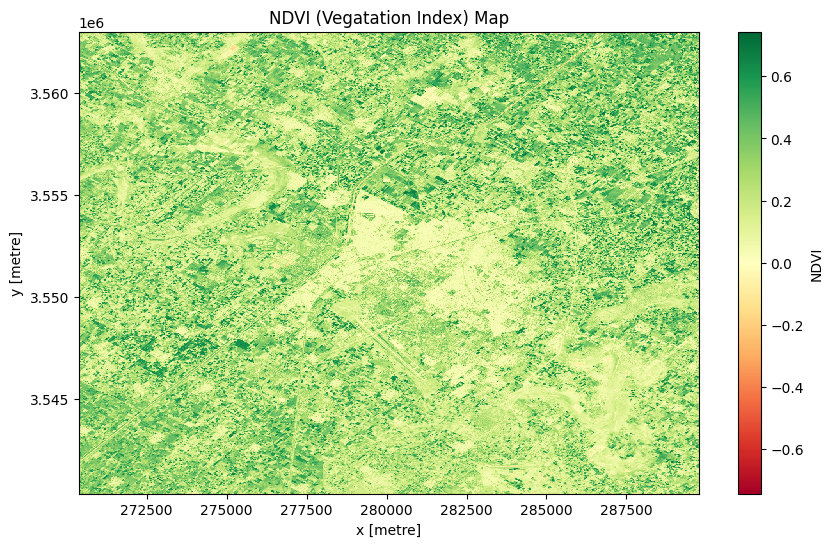

In [17]:
def calculate_indices(ds):
    nir, red, green, swir = ds.B08, ds.B04, ds.B03, ds.B11
    ds['NDVI'] = (nir - red) / (nir + red + 1e-8)
    ds['NDWI'] = (green - nir) / (green + nir + 1e-8)
    ds['NDBI'] = (swir - nir) / (swir + nir + 1e-8)
    return ds

ds = calculate_indices(ds)

# Visualize NDVI
plt.figure(figsize=(10, 6))
ds.NDVI.plot(cmap='RdYlGn')
plt.title("NDVI (Vegatation Index) Map")
plt.show()

## 4. Preparing Training Data
Since we don't have ground truth labels for this exact image, we will **simulate labels** based on spectral thresholds for demonstration purposes (Vegetation, Water, Urban, Bare Soil).

In [18]:
def simulate_labels(ds):
    # Simplified threshold-based labeling for demonstration
    label = np.zeros(ds.NDVI.shape, dtype=int)
    label = np.where(ds.NDWI > 0.1, 1, label)      # Water
    label = np.where(ds.NDVI > 0.4, 2, label)      # Dense Vegetation
    label = np.where((ds.NDBI > 0.1) & (label==0), 3, label) # Urban/Built-up
    return label

labels = simulate_labels(ds)
df = ds.to_dataframe().dropna().reset_index(drop=True)
df['label'] = labels.flatten()[:len(df)]

X = df.drop(columns=['label', 'time', 'spatial_ref'], errors='ignore')
y = df['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Classes distribution:\n{y.value_counts()}")

Classes distribution:
label
0    830028
2    226142
3     36892
1      1908
Name: count, dtype: int64


## 5. Model Comparison: Random Forest vs XGBoost

In this section, we compare two powerful ensemble learning methods: **Random Forest** (a Bagging method) and **XGBoost** (a Boosting method).

### Random Forest (Bagging - Bootstrap Aggregating)
Random Forest builds multiple decision trees independently and in parallel. Each tree is trained on a random subset of the data (bootstrapping) and a random subset of features. The final prediction is determined by a majority vote of all trees. This approach significantly reduces **variance** and prevents overfitting.

**Architecture Diagram:**
```mermaid
graph TD
    Data[Original Dataset] --> B1[Bootstrap Sample 1]
    Data --> B2[Bootstrap Sample 2]
    Data --> B3[Bootstrap Sample N]
    B1 --> T1[Decision Tree 1]
    B2 --> T2[Decision Tree 2]
    B3 --> TN[Decision Tree N]
    T1 --> P1[Prediction 1]
    T2 --> P2[Prediction 2]
    TN --> PN[Prediction N]
    P1 --> V[Final Aggregation / Voting]
    P2 --> V
    PN --> V
    V --> Final[Final Class Prediction]
    
    style Data fill:#f9f,stroke:#333,stroke-width:2px
    style Final fill:#bfb,stroke:#333,stroke-width:2px
```

### XGBoost (Boosting)
Extreme Gradient Boosting (XGBoost) builds trees sequentially. Each new tree focuses on correcting the errors (residuals) made by the ensemble of previous trees. By minimizing a loss function via gradient descent, it mathematically combines them into a single strong model, often reducing **bias** and yielding state-of-the-art accuracy on complex geospatial data.

**Architecture Diagram:**
```mermaid
graph LR
    Data[Dataset] --> T1[Tree 1]
    T1 --> E1[Residual Errors]
    E1 -- focus --> T2[Tree 2]
    T2 --> E2[Residual Errors]
    E2 -- focus --> T3[Tree 3]
    T3 --> Final[Final Strong Classifier]
    
    style Data fill:#f9f,stroke:#333,stroke-width:2px
    style Final fill:#bfb,stroke:#333,stroke-width:2px
```

In [19]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

# 2. XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"XGBoost Accuracy:       {xgb_acc:.4f}")

Random Forest Accuracy: 1.0000
XGBoost Accuracy:       0.9983


## 6. Hyperparameter Tuning & Model Optimization

To get the best performance out of our models, we need to tune their **Hyperparameters**. Unlike parameters learned during training, hyperparameters are set before the process starts.

### Tuning Strategies
- **Grid Search**: Exhaustively tries every combination of parameters in a grid.
- **Random Search**: Samples a fixed number of parameter combinations from specified distributions. This is often more efficient than Grid Search.

**Tuning Flow:**
```mermaid
graph LR
    P[Parameters] --> RS[Randomized Search]
    RS --> CV[Cross-Validation]
    CV --> EB[Evaluate Best Model]
    EB --> Final[Final Optimized Model]
```

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# 2. Initialize the model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# 3. Initialize Randomized Search
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_grid, n_iter=5, cv=3, verbose=1, n_jobs=-1)

# 4. Fit the model
print("Starting Hyperparameter Tuning...")
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

In [ ]:
best_model = random_search.best_estimator_

## 7. Handling Imbalanced Data with SMOTE
Satellite data often has imbalanced classes (e.g., very little water). Synthetic Minority Over-sampling Technique (SMOTE) creates synthetic samples for minority classes.

In [21]:
from imblearn.over_sampling import SMOTE

print(f"Original distribution: {y_train.value_counts(normalize=True).to_dict()}")
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print(f"Resampled distribution: {y_res.value_counts(normalize=True).to_dict()}")

best_model.fit(X_res, y_res)
print("Model retrained with balanced data.")

Original distribution: {0: 0.7580377283656825, 2: 0.206527510864616, 3: 0.03369172540930671, 1: 0.00174303536039474}
Resampled distribution: {2: 0.25, 0: 0.25, 3: 0.25, 1: 0.25}
Model retrained with balanced data.


## 8. Final Classification Map
We apply the trained model back to the entire dataset to generate the land cover map.

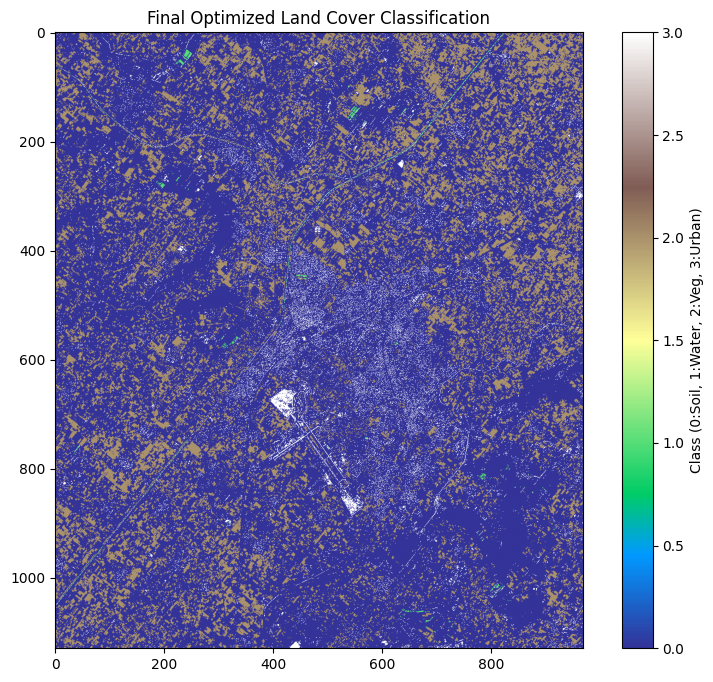

In [22]:
full_pred = best_model.predict(X)
prediction_map = full_pred.reshape(ds.NDVI.shape)

plt.figure(figsize=(10, 8))
plt.imshow(prediction_map, cmap='terrain')
plt.colorbar(label='Class (0:Soil, 1:Water, 2:Veg, 3:Urban)')
plt.title("Final Optimized Land Cover Classification")
plt.show()